In [1]:
#Testing Python Works
print('hello world')

hello world


In [ ]:
#Building a Linear Regression Model to Predict Yearly Amount Spent by an Ecommerce Platform Visitors
#The model predicts how much a customer spends on an ecommerce platform per year based on parameters like Time on Phone App,Time on Website,Average Session Length and Length of Membership

In [ ]:
#Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle

In [60]:
#We now load our dataset
df = pd.read_csv("archive/ecommerce.csv")

In [61]:
#We look at the dataset to understand it better
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [62]:
#Looking at the dataset for more info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


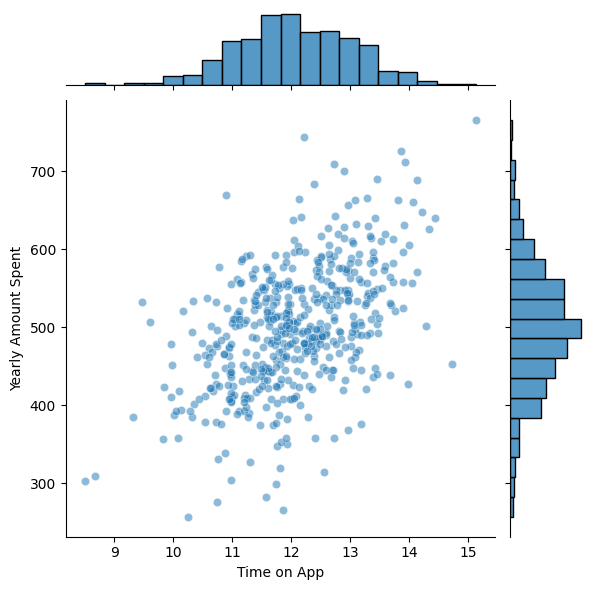

In [63]:
# Exploratory Data Analysis
# A jointplot to compare the relationship between the variable Time on App and the target Yearly Amount Spent
sns.jointplot(data=df, x="Time on App" , y="Yearly Amount Spent", alpha=0.5  )

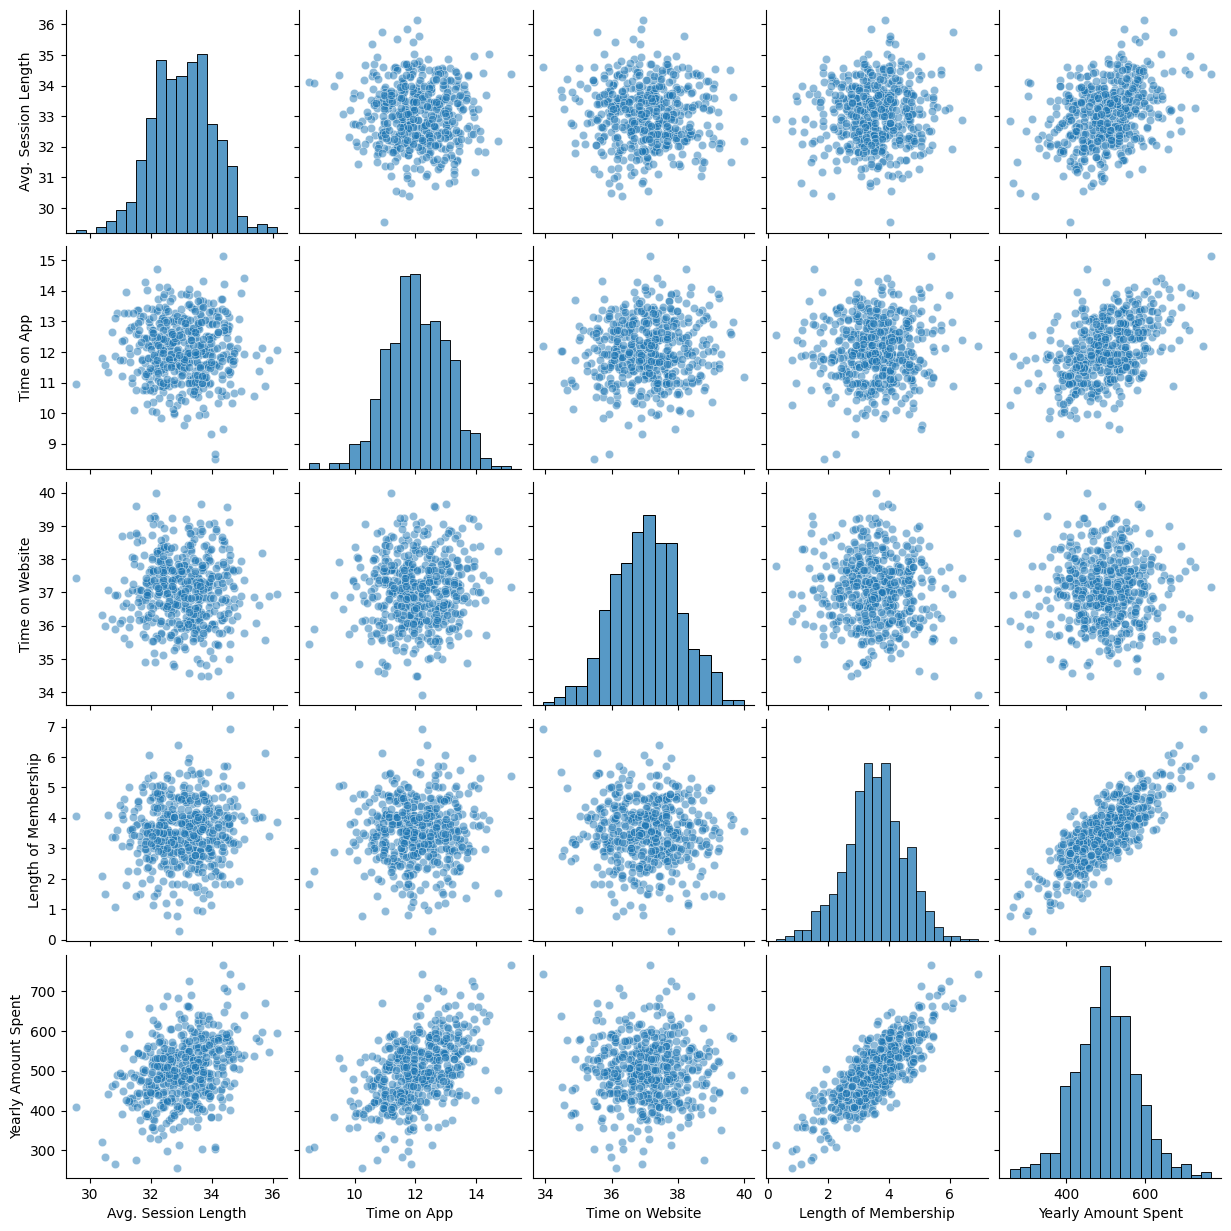

In [64]:
#Now a pairplot of the dataset 
sns.pairplot(data=df, kind='scatter', plot_kws={'alpha': 0.5})

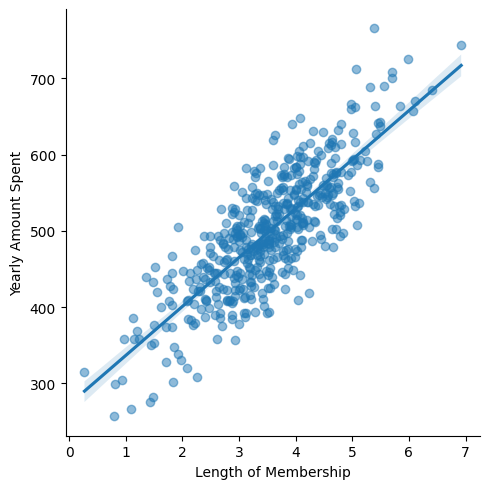

In [65]:
#We now build a Linear Regression Model Using the variable(Assume one variable at the moment) Length of Membership again Yearly Amount Spent
sns.lmplot(
    data=df,
    x="Length of Membership",
    y="Yearly Amount Spent",
    scatter_kws={'alpha': 0.5}
)

In [66]:
#Now we move to creating our Linear Regression Model with all the variables considered

In [67]:
#We start by importing the train,test and split commands in scikit-learn
from sklearn.model_selection import train_test_split

In [68]:
#We set the variables and output of the model
#Note that the capitalization in x variable is to represent an array of variables
X= df[['Avg. Session Length', 'Time on App', 'Time on Website','Length of Membership']]
y= df['Yearly Amount Spent']

In [69]:
#Now we split the dataset into the respective training and testing segments
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.32, random_state=42)

In [70]:
#Print X train
X_train 

,Avg. Session Length,Time on App,Time on Website,Length of Membership
110,31.853075,12.149375,37.325334,3.361815
318,33.531860,13.665770,36.900221,3.515688
428,31.862741,14.039867,37.022269,3.738225
29,33.105438,11.965020,37.277812,4.742578
437,31.967321,11.481587,39.240965,3.532517
...,...,...,...,...
106,32.291756,12.190474,36.152462,3.781823
270,34.006489,12.956277,38.655095,3.275734
348,31.812483,10.886921,34.897828,3.128639
435,32.259973,14.132893,37.023479,3.762070


In [71]:
#Training the model

In [72]:
from sklearn.linear_model import LinearRegression
lm= LinearRegression()

In [73]:
#Pass in the training dataset portion
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
#Visualizing our coefficients
cdf= pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(cdf)

                      Coefficient
Avg. Session Length     25.728496
Time on App             38.539653
Time on Website          0.576211
Length of Membership    61.662859


In [75]:
#Making Predictions

In [76]:
predictions= lm.predict(X_test)

In [77]:
predictions

array([403.90294289, 542.43106472, 427.18360686, 501.87482929,
       410.20081164, 569.8838258 , 531.70829604, 506.27484339,
       408.74614298, 474.01163117, 441.39759115, 425.39339678,
       424.8721908 , 527.51178284, 431.51488296, 423.95339772,
       575.50711842, 484.69109074, 458.29397574, 481.9071137 ,
       502.34001851, 513.54167202, 507.47148498, 646.4716347 ,
       450.13801447, 495.99748029, 556.47230154, 554.7409352 ,
       399.63318968, 325.7858759 , 532.75818775, 478.17056869,
       500.94128674, 305.91263457, 505.71848   , 483.57653589,
       518.51427458, 438.01592275, 456.71707806, 471.01479644,
       494.27628306, 445.23081746, 508.60372093, 500.93500287,
       488.90004159, 535.17455834, 595.36655323, 513.98427125,
       280.96947124, 433.13530713, 421.8025851 , 481.17394359,
       584.80000322, 608.8123247 , 563.71378151, 494.45406649,
       394.41895732, 456.33117644, 572.84191491, 499.79307393,
       512.78048557, 392.03794902, 480.08104574, 481.46

Text(0.5, 1.0, 'Predictions vs Actual Values')

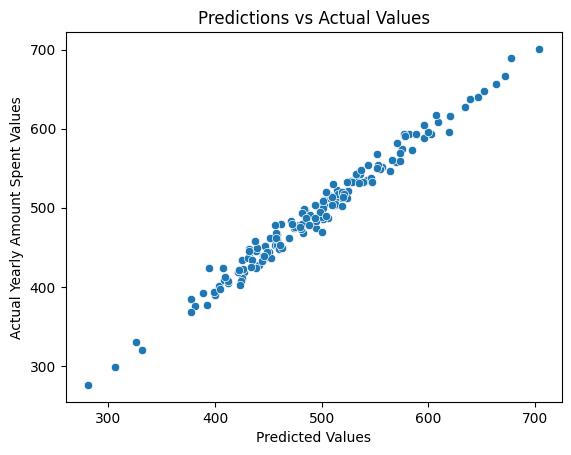

In [78]:
#We make a scatterplot of the predictions against the actual output values
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Yearly Amount Spent Values")
plt.title("Predictions vs Actual Values")

In [79]:
#Other Evaluation Metrics in Scikit-Learn
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [80]:
print('Mean Absolute Error: ', mean_absolute_error(y_test,predictions))
print('Mean Squared Error: ', mean_squared_error(y_test,predictions))
print('RMSE: ', math.sqrt(mean_squared_error(y_test,predictions)))

Mean Absolute Error:  8.363747215328194
Mean Squared Error:  102.65764119388123
RMSE:  10.132010718207972


In [81]:
#Residuals

In [82]:
residuals= y_test- predictions
residuals

361    -2.869808
73     -7.653877
374    -8.580865
155     2.103550
104    -0.131201
         ...    
357    -7.484926
3      11.487212
218    -1.384198
405     7.684857
60     10.091589
Name: Yearly Amount Spent, Length: 160, dtype: float64

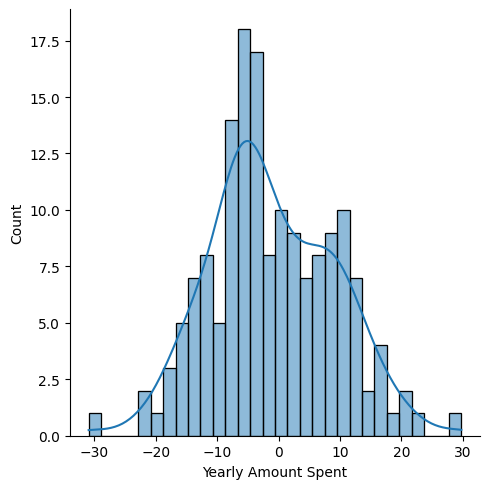

In [83]:
#Testing for normality in the residuals(the residuals should be normally distributed for a good linear model)
sns.displot(residuals, bins=30, kde=True)

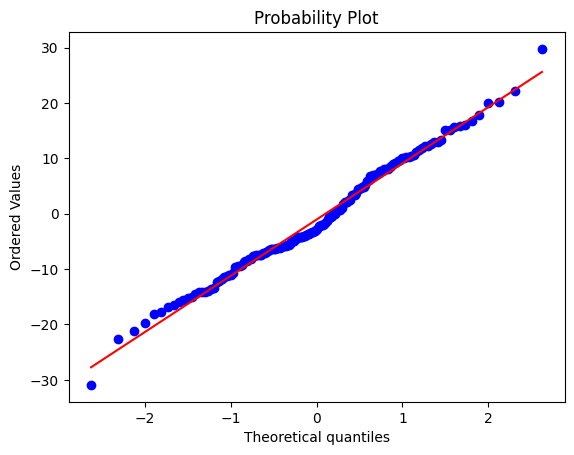

In [84]:
#You can also use a qq plot for testing normality
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist='norm', plot=pylab)
pylab.show()

In [85]:
#Testing on new and unseen data
new_customer = pd.DataFrame({
    "Avg. Session Length":[34],
    "Time on App":[12],
    "Time on Website":[30],
    "Length of Membership":[6]
})

prediction = lm.predict(new_customer)

print('Estimated Yearly Amount Spent: ', prediction)

Estimated Yearly Amount Spent:  [670.01637462]


In [ ]:
# Save the trained model
with open("linear_model.pkl", "wb") as f:
    pickle.dump(lm, f)

print("Model saved successfully!")